# 01 — Exploratory Data Analysis

Before any preprocessing or modeling, this notebook works through the Amazon Reviews 2023 data for the two categories chosen for the seminar: Subscription Boxes and Magazine Subscriptions. The aim is to understand the dataset well enough to make informed methodological choices for RQ1 (sentiment classification) and RQ2 (aspect-based analysis).

**What this notebook produces:**
- Dataset overview, time range, basic field health
- Star rating distribution overall and by category
- Class imbalance under binary and ternary sentiment framings
- Review length statistics and a histogram (extreme outliers reported separately)
- Review volume over time, motivating the train/test split strategy
- Vocabulary size estimate from a 20K-review sample
- Discriminative-word preview as a sanity check (supplementary)
- Summary table saved to `results/tables/eda_summary.csv`

All figures are written to `results/figures/` so they can be reused in the interim presentation and the final paper.

In [ ]:
import sys
from pathlib import Path
from collections import Counter
import re
import math

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
RANDOM_STATE = 42

FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

NAVY = '#1E3A6E'
BLUE = '#5B8DBF'
ORANGE = '#D97757'

## 1. Loading the two categories

Subscription Boxes (~16K reviews, 641 items) and Magazine Subscriptions (~71K reviews, 3.4K items) are the two smallest categories in the Amazon Reviews 2023 release. Working with the smallest categories keeps things tractable on a laptop, and selecting two of them — rather than just one — preserves the cross-category comparison that RQ2 requires.

In [2]:
SUBSCRIPTION_BOXES = PROJECT_ROOT / 'data' / 'raw' / 'Subscription_Boxes.jsonl'
MAGAZINE_SUBS = PROJECT_ROOT / 'data' / 'raw' / 'Magazine_Subscriptions.jsonl'

df_boxes = pd.read_json(SUBSCRIPTION_BOXES, lines=True)
df_boxes['category'] = 'Subscription_Boxes'

df_mags = pd.read_json(MAGAZINE_SUBS, lines=True)
df_mags['category'] = 'Magazine_Subscriptions'

df = pd.concat([df_boxes, df_mags], ignore_index=True)
print(f'Total reviews: {len(df):,}')
print(f'\nBy category:')
print(df['category'].value_counts())
df.head(3)

Total reviews: 87,713

By category:
category
Magazine_Subscriptions    71497
Subscription_Boxes        16216
Name: count, dtype: int64


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category
0,1,USELESS,Absolutely useless nonsense and a complete was...,[],B07G584SHG,B09WC47S3V,AEMJ2EG5ODOCYUTI54NBXZHDJGSQ,2020-10-08 05:10:57.705,2,True,Subscription_Boxes
1,2,Manufactured where?,"With a couple of the items, I wasn't quite sur...",[],B07QL1JRCN,B07QL1JRCN,AEEJBFZKUBEEMBZUZJV4UHFVEEBQ,2020-12-27 23:12:15.433,20,True,Subscription_Boxes
2,1,Little bang for your buck.,Two SMALL stuffed animals and 2 little bags of...,[],B07RBYJN37,B08N5QKX1Y,AGSVZNZBTSGQBKZDZTQYEZHGDPCQ,2021-01-06 12:48:35.319,4,True,Subscription_Boxes


### Dataset structure and time range

In [ ]:
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')

print('Columns:', df.columns.tolist())
print(f"\nTime range: {df['date'].min().date()}  ->  {df['date'].max().date()}")
print(f"\nVerified-purchase share: {df['verified_purchase'].mean():.1%}")
print(f"\nMissing values per column:")
print(df[['rating', 'title', 'text']].isna().sum())
print(f"\nEmpty review texts: {(df['text'].str.len() == 0).sum()}")

Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'category', 'date']

Time range: 2001-10-26  ->  2023-08-30

Verified-purchase share: 82.7%

Missing values per column:
rating    0
title     0
text      0
dtype: int64

Empty review texts: 1


## 2. Star rating distribution

Star ratings are the natural source of sentiment labels. The shape of this distribution determines how (im)balanced the resulting classes will be — a key constraint for everything in RQ1.

Overall star distribution:
        count  percent
rating                
1       12261     14.0
2        5444      6.2
3        6785      7.7
4        9869     11.3
5       53354     60.8


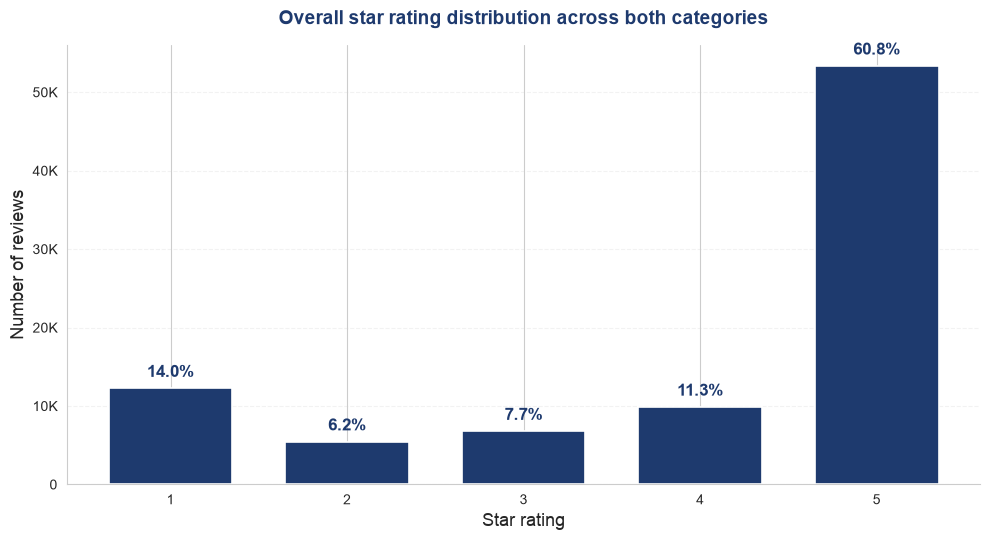

In [4]:
rating_counts = df['rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(1)

summary = pd.DataFrame({'count': rating_counts, 'percent': rating_pct})
print('Overall star distribution:')
print(summary)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(rating_counts.index.astype(int), rating_counts.values,
              color=NAVY, edgecolor='white', linewidth=1.2, width=0.7)
for bar, pct in zip(bars, rating_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{pct}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color=NAVY)
ax.set_title('Overall star rating distribution across both categories',
             fontsize=14, color=NAVY, fontweight='bold', pad=15)
ax.set_xlabel('Star rating', fontsize=13)
ax.set_ylabel('Number of reviews', fontsize=13)
ax.set_xticks([1, 2, 3, 4, 5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'star_distribution_overall.png')
plt.show()

**Reading.** The distribution is heavily skewed toward 5-star reviews, with a smaller secondary peak at 1-star and very few 2- and 3-star ratings. This U-shaped pattern is commonly observed in online review datasets: customers who post tend to be either very satisfied or actively frustrated, while moderate experiences are under-represented. Practically, this means RQ1's models will face strong imbalance, and accuracy alone will be a misleading metric.

### Per-category breakdown

Worth checking before moving on: do both categories show the same imbalance pattern, or is one much more polarized than the other? This matters for RQ2, since systematic differences in label distribution between categories would complicate any cross-category comparison.

Star distribution by category (percent):
category  Magazine_Subscriptions  Subscription_Boxes
rating                                              
1                           13.5                15.9
2                            5.5                 9.2
3                            7.0                10.8
4                           11.5                10.3
5                           62.4                53.9


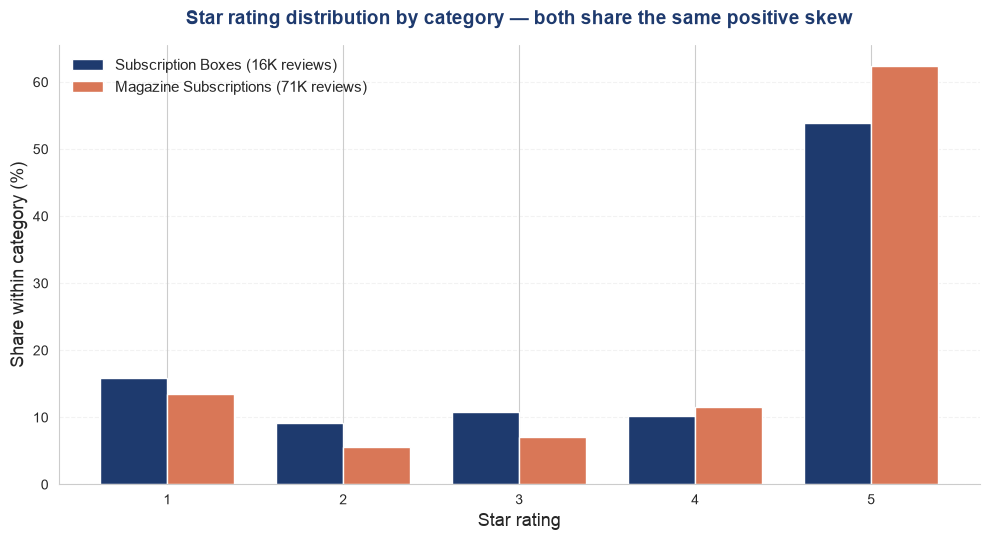

In [5]:
ct_pct = pd.crosstab(df['rating'], df['category'], normalize='columns') * 100
print('Star distribution by category (percent):')
print(ct_pct.round(1))

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(1, 6)
width = 0.38
ax.bar(x - width/2, ct_pct['Subscription_Boxes'], width,
       label='Subscription Boxes (16K reviews)', color=NAVY, edgecolor='white', linewidth=1)
ax.bar(x + width/2, ct_pct['Magazine_Subscriptions'], width,
       label='Magazine Subscriptions (71K reviews)', color=ORANGE, edgecolor='white', linewidth=1)
ax.set_title('Star rating distribution by category — both share the same positive skew',
             fontsize=14, color=NAVY, fontweight='bold', pad=15)
ax.set_xlabel('Star rating', fontsize=13)
ax.set_ylabel('Share within category (%)', fontsize=13)
ax.set_xticks(x)
ax.legend(frameon=False, fontsize=11, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'star_distribution_by_category.png')
plt.show()

**Reading.** Both categories show a similar positive skew, which suggests the imbalance is not specific to either product type within this sample. The similar label distribution means a combined classifier won't be biased *by design* toward one category over the other — but how it actually performs across categories is an empirical question that depends on vocabulary and aspect differences, not just on label balance. Per-category evaluation in RQ1 will surface any divergence.

Subtle differences — for example, whether one category is slightly more polarized than the other — are worth keeping in mind when interpreting per-category aspect-sentiment profiles in RQ2.

## 3. Class imbalance under two sentiment framings

There are two common ways to map star ratings to sentiment labels:

- **Binary:** 1–2 stars = negative, 4–5 stars = positive, drop 3-star reviews.
- **Ternary:** 1–2 = negative, 3 = neutral, 4–5 = positive.

Each has trade-offs. Binary gives cleaner classes but throws away the most ambiguous cases. Ternary keeps everything but introduces a small, hard-to-classify middle class. The interim presentation will raise this as an open decision; both are computed below.

In [6]:
def map_binary(r):
    if r <= 2:
        return 'negative'
    if r >= 4:
        return 'positive'
    return None  # 3-star excluded

def map_ternary(r):
    if r <= 2:
        return 'negative'
    if r == 3:
        return 'neutral'
    return 'positive'

df['sentiment_binary'] = df['rating'].apply(map_binary)
df['sentiment_ternary'] = df['rating'].apply(map_ternary)

binary_counts = df['sentiment_binary'].value_counts()
ternary_counts = df['sentiment_ternary'].value_counts()

print('Binary framing (3-star reviews dropped):')
print(binary_counts)
ratio = binary_counts['positive'] / binary_counts['negative']
print(f"\n  Imbalance ratio (positive : negative) = {ratio:.2f} : 1")
print(f"  Reviews retained: {binary_counts.sum():,} ({binary_counts.sum() / len(df):.1%} of total)")

print('\n\nTernary framing (all reviews):')
print(ternary_counts)
neg, neu, pos = ternary_counts['negative'], ternary_counts['neutral'], ternary_counts['positive']
print(f'\n  Distribution: {pos/len(df):.1%} positive | {neu/len(df):.1%} neutral | {neg/len(df):.1%} negative')
print(f'  Imbalance: majority class is {pos / neu:.1f}x larger than the smallest (neutral)')

Binary framing (3-star reviews dropped):
sentiment_binary
positive    63223
negative    17705
Name: count, dtype: int64

  Imbalance ratio (positive : negative) = 3.57 : 1
  Reviews retained: 80,928 (92.3% of total)


Ternary framing (all reviews):
sentiment_ternary
positive    63223
negative    17705
neutral      6785
Name: count, dtype: int64

  Distribution: 72.1% positive | 7.7% neutral | 20.2% negative
  Imbalance: majority class is 9.3x larger than the smallest (neutral)


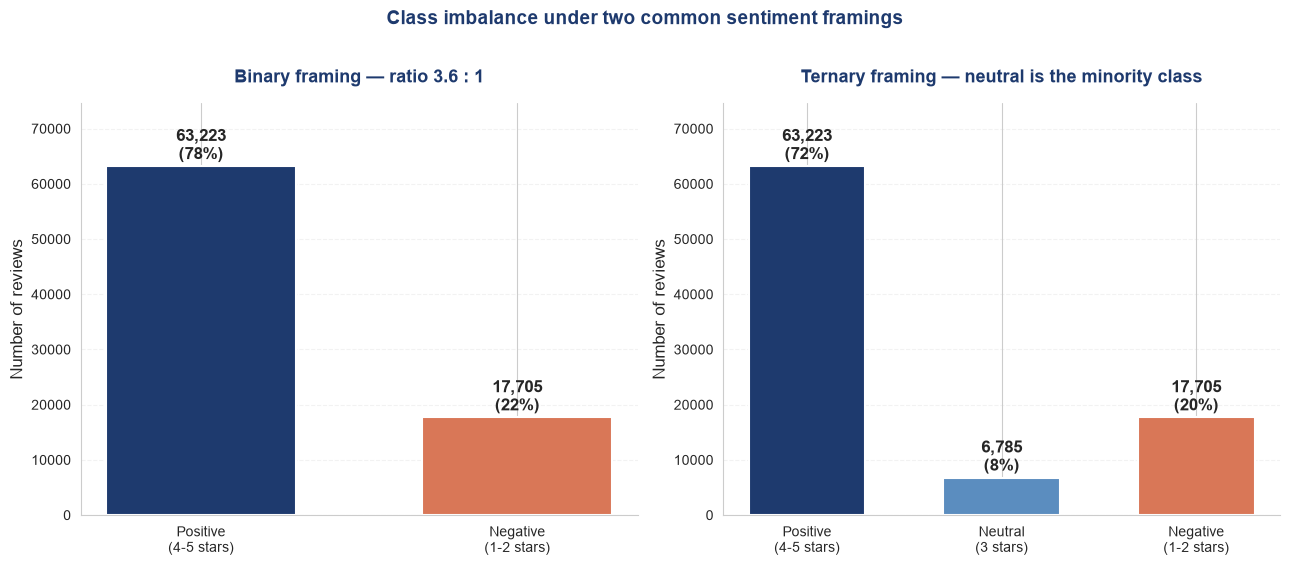

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

binary_order = ['positive', 'negative']
binary_vals = [binary_counts.get(c, 0) for c in binary_order]
labels1 = ['Positive\n(4-5 stars)', 'Negative\n(1-2 stars)']
bars1 = ax1.bar(labels1, binary_vals, color=[NAVY, ORANGE], edgecolor='white', linewidth=1.5, width=0.6)
for bar, v in zip(bars1, binary_vals):
    pct = v / sum(binary_vals) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(binary_vals)*0.02,
             f'{v:,}\n({pct:.0f}%)', ha='center', fontsize=12, fontweight='bold')
ax1.set_title(f'Binary framing — ratio {binary_vals[0]/binary_vals[1]:.1f} : 1',
              fontsize=13, color=NAVY, fontweight='bold', pad=15)
ax1.set_ylabel('Number of reviews', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, max(binary_vals) * 1.18)
ax1.grid(axis='y', alpha=0.25, linestyle='--')
ax1.set_axisbelow(True)

ternary_order = ['positive', 'neutral', 'negative']
ternary_vals = [ternary_counts.get(c, 0) for c in ternary_order]
labels2 = ['Positive\n(4-5 stars)', 'Neutral\n(3 stars)', 'Negative\n(1-2 stars)']
bars2 = ax2.bar(labels2, ternary_vals, color=[NAVY, BLUE, ORANGE], edgecolor='white', linewidth=1.5, width=0.6)
for bar, v in zip(bars2, ternary_vals):
    pct = v / sum(ternary_vals) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ternary_vals)*0.02,
             f'{v:,}\n({pct:.0f}%)', ha='center', fontsize=12, fontweight='bold')
ax2.set_title('Ternary framing — neutral is the minority class',
              fontsize=13, color=NAVY, fontweight='bold', pad=15)
ax2.set_ylabel('Number of reviews', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylim(0, max(ternary_vals) * 1.18)
ax2.grid(axis='y', alpha=0.25, linestyle='--')
ax2.set_axisbelow(True)

plt.suptitle('Class imbalance under two common sentiment framings',
             fontsize=14, color=NAVY, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_imbalance.png')
plt.show()

**Reading.** Two takeaways for RQ1:

1. **The binary framing yields a moderate imbalance of roughly 3.6 : 1.** This imbalance can be addressed with class weighting in models that support it (`LogisticRegression`) or sample weights in `sklearn.ensemble.GradientBoostingClassifier`. For Multinomial Naive Bayes, which doesn't accept class weights directly, alternatives are random under- or oversampling, or adjusting class priors. SMOTE is sometimes mentioned in this context, but interpolating synthetic points in a sparse high-dimensional TF-IDF space is methodologically debatable and will not be the default approach here.
2. **The ternary framing puts the neutral 3-star class in the minority position** at roughly 8% of the data — and that's exactly the population RQ1 wants to investigate, since 3-star reviews are typically where mixed sentiment lives.

The methodological consequence is straightforward: accuracy alone is uninformative here. A trivial *always-predict-positive* baseline already reaches ~78% accuracy under the binary framing and ~72% under the ternary one. Macro-F1 and per-class recall will be the primary metrics in RQ1, with accuracy reported only as supplementary.

## 4. Review length

Review length isn't just a curiosity — it shapes feature engineering. Very short reviews carry little signal for any bag-of-words representation, and very long ones can dominate certain models if not handled carefully. The summary statistics and the histogram below sketch the overall picture.

In [8]:
df['review_length'] = df['text'].fillna('').str.split().str.len()

print('Overall review length (words):')
print(df['review_length'].describe().round(1))
print(f"\nReviews with 0-5 words: {(df['review_length'] <= 5).sum():,} "
      f"({(df['review_length'] <= 5).mean():.1%})")
print(f"Reviews with 1000+ words: {(df['review_length'] >= 1000).sum():,}")

print('\n\nBy category (review length):')
print(df.groupby('category')['review_length'].agg(['mean', 'median', 'std']).round(1))

Overall review length (words):
count    87713.0
mean        40.0
std         62.8
min          0.0
25%          9.0
50%         22.0
75%         47.0
max       4888.0
Name: review_length, dtype: float64

Reviews with 0-5 words: 14,847 (16.9%)
Reviews with 1000+ words: 14


By category (review length):
                        mean  median   std
category                                  
Magazine_Subscriptions  38.3    21.0  63.6
Subscription_Boxes      47.4    30.0  58.6


Reviews above 300 words excluded from histogram: 733 (0.84%)


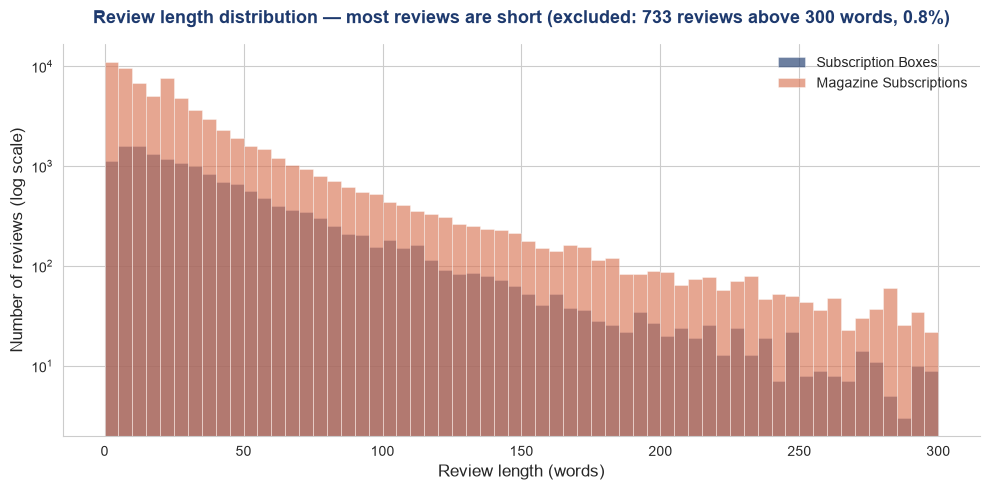

In [ ]:

MAX_LEN = 300
n_excluded = (df['review_length'] > MAX_LEN).sum()
pct_excluded = n_excluded / len(df) * 100
print(f'Reviews above {MAX_LEN} words excluded from histogram: {n_excluded:,} ({pct_excluded:.2f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
for cat, color in zip(['Subscription_Boxes', 'Magazine_Subscriptions'], [NAVY, ORANGE]):
    subset = df[(df['category'] == cat) & (df['review_length'] <= MAX_LEN)]['review_length']
    ax.hist(subset, bins=60, alpha=0.65, label=cat.replace('_', ' '),
            color=color, edgecolor='white', linewidth=0.4)
ax.set_yscale('log')
ax.set_title(f'Review length distribution — most reviews are short (excluded: {n_excluded:,} reviews above {MAX_LEN} words, {pct_excluded:.1f}%)',
             fontsize=13, color=NAVY, fontweight='bold', pad=15)
ax.set_xlabel('Review length (words)', fontsize=12)
ax.set_ylabel('Number of reviews (log scale)', fontsize=12)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'review_length_histogram.png')
plt.show()

**Reading.** Review length is heavily right-skewed: the median sits around 22 words, the 75th percentile around 47, and the maximum runs into the thousands. Most reviews are short — only a handful of sentences — which has two practical consequences. First, very short reviews (≤5 words) carry limited information and may need to be filtered or down-weighted. Second, the short median strongly supports the sentence-level approach planned for RQ2: when a review is only two or three sentences long, splitting it into sentences for aspect attribution is a natural unit, not a forced one.

## 5. Reviews over time

Both categories cover a long time range (2001–2023, see the computed time range in Section 1 above). A chronological view of review volume reveals temporal patterns that any modeling pipeline must respect — particularly when choosing a train/test split.

Reviews per year (most recent 10):
category  Magazine_Subscriptions  Subscription_Boxes
year                                                
2014                        6903                   0
2015                        7163                   0
2016                        6478                   0
2017                        5932                 730
2018                        5920                1947
2019                        6914                3088
2020                        5748                4244
2021                        4303                3674
2022                        2027                2066
2023                         292                 467


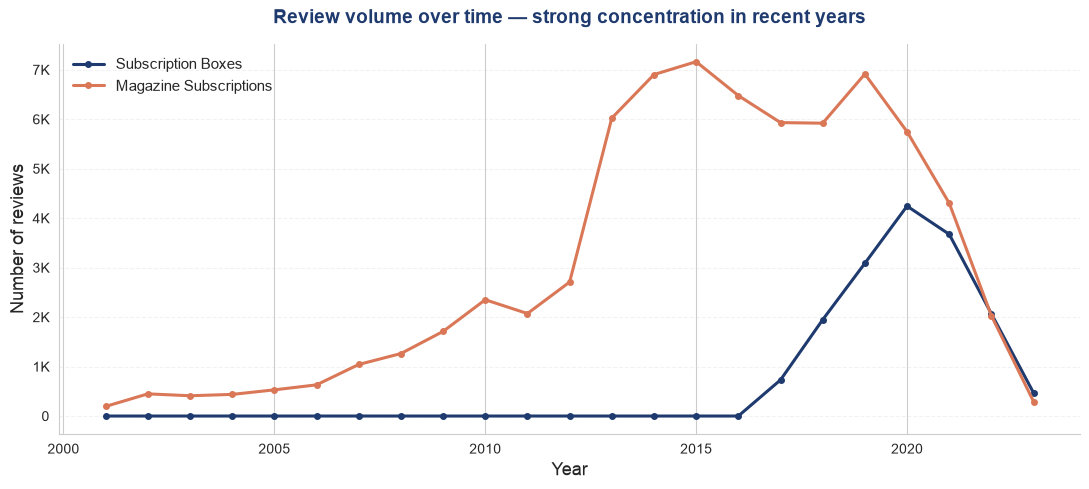

In [10]:
df['year'] = df['date'].dt.year
yearly = df.groupby(['year', 'category']).size().unstack(fill_value=0)

print('Reviews per year (most recent 10):')
print(yearly.tail(10))

fig, ax = plt.subplots(figsize=(11, 5))
yearly['Subscription_Boxes'].plot(ax=ax, color=NAVY, linewidth=2.2,
                                   marker='o', markersize=4, label='Subscription Boxes')
yearly['Magazine_Subscriptions'].plot(ax=ax, color=ORANGE, linewidth=2.2,
                                       marker='o', markersize=4, label='Magazine Subscriptions')
ax.set_title('Review volume over time — strong concentration in recent years',
             fontsize=14, color=NAVY, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Number of reviews', fontsize=13)
ax.legend(frameon=False, fontsize=11, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reviews_over_time.png')
plt.show()

**Reading.** Review volume grows substantially over time, with most data concentrated in the most recent years. Two methodological consequences follow.

First, **a chronological train/test split is the appropriate choice.** A random split would mix older and newer reviews across training and test sets, which doesn't reflect how a deployed sentiment model would actually be used. A chronological split — older reviews for training, newer for evaluation — better simulates real-world deployment, where the model is always asked to score new reviews based on patterns learned from past ones.

Second, **vocabulary and language drift over time.** Slang, brand names, and even sentiment expressions shift across decades. The discriminative-word analysis later in the notebook should therefore be read with awareness that it reflects recent reviews more than older ones.

## 6. Vocabulary size estimate

A quick whitespace-tokenized vocabulary count from a 20K-review sample gives a rough sense of feature space dimensionality. The full vocabulary will be slightly larger once all reviews are included, but the order of magnitude is what matters here.

In [ ]:
def quick_tokens(text):
    if not isinstance(text, str):
        return []
    return re.findall(r"[a-zA-Z]+", text.lower())


sample = df.sample(n=min(20000, len(df)), random_state=RANDOM_STATE)
vocab_counter = Counter()
total_tokens = 0
for txt in sample['text'].fillna(''):
    toks = quick_tokens(txt)
    vocab_counter.update(toks)
    total_tokens += len(toks)

print(f'Sample size: {len(sample):,} reviews')
print(f'Total tokens: {total_tokens:,}')
print(f'Unique tokens (vocabulary size, raw): {len(vocab_counter):,}')
print(f'Tokens appearing 5+ times: {sum(1 for c in vocab_counter.values() if c >= 5):,}')
print(f'Tokens appearing 20+ times: {sum(1 for c in vocab_counter.values() if c >= 20):,}')
print(f'\n=> Sample vocabulary with corpus frequency >= 5: {sum(1 for c in vocab_counter.values() if c >= 5):,} terms')

Sample size: 20,000 reviews
Total tokens: 803,971
Unique tokens (vocabulary size, raw): 21,676
Tokens appearing 5+ times: 6,308
Tokens appearing 20+ times: 2,567

=> Sample vocabulary with corpus frequency >= 5: 6,308 terms


**Reading.** Based on the 20K-review sample, the descriptive sample vocabulary contains the terms whose corpus frequency is at least five. This is not the final TF-IDF `min_df=5` vocabulary, because the actual TF-IDF vocabulary is fitted on the training split alone to keep the evaluation honest. The sample count is used only as an order-of-magnitude corpus statistic. With bigrams added, the feature space grows but stays well under 100K — comfortably tractable for classical models without dimensionality reduction.

## 7. Discriminative words per sentiment class *(supplementary)*

*This section is supplementary, not a core EDA finding. It serves two purposes: a sanity check that the dataset has learnable signal at all, and a preview of the kinds of words a TF-IDF + linear model is likely to pick up in RQ1. It is not a model interpretation — that comes later, after actual classifiers are trained.*

In [12]:
STOPWORDS_QUICK = set('''a an the and or but if of to for in on at by with as is are was were be been being
have has had do does did this that these those i you he she it we they me him her us them my your his their our
not no so just also too very really quite much many some any all only more most less than then now
would could should can will from about what there here out one get got don did didn i'm i've it's
also because when where who whom which while into over under again item items thing things way time'''.split())

def top_words(texts, n=20):
    c = Counter()
    for t in texts:
        c.update(w for w in quick_tokens(t) if w not in STOPWORDS_QUICK and len(w) > 2)
    return c.most_common(n)

pos_texts = df[df['sentiment_binary'] == 'positive']['text'].fillna('')
neg_texts = df[df['sentiment_binary'] == 'negative']['text'].fillna('')

top_pos = top_words(pos_texts.sample(n=min(10000, len(pos_texts)), random_state=RANDOM_STATE))
top_neg = top_words(neg_texts.sample(n=min(10000, len(neg_texts)), random_state=RANDOM_STATE))

print('Top 15 words in positive reviews:')
for w, c in top_pos[:15]:
    print(f'  {w:<15} {c:>5,}')
print('\nTop 15 words in negative reviews:')
for w, c in top_neg[:15]:
    print(f'  {w:<15} {c:>5,}')

Top 15 words in positive reviews:
  magazine        5,706
  great           3,052
  love            2,397
  good            1,596
  articles        1,523
  like            1,517
  subscription    1,348
  read            1,280
  box               991
  issue             979
  always            921
  new               893
  every             885
  well              840
  month             835

Top 15 words in negative reviews:
  magazine        6,840
  subscription    3,596
  like            2,271
  issue           2,045
  received        1,941
  box             1,909
  first           1,437
  issues          1,301
  year            1,276
  articles        1,273
  amazon          1,210
  even            1,173
  good            1,162
  after           1,152
  money           1,064


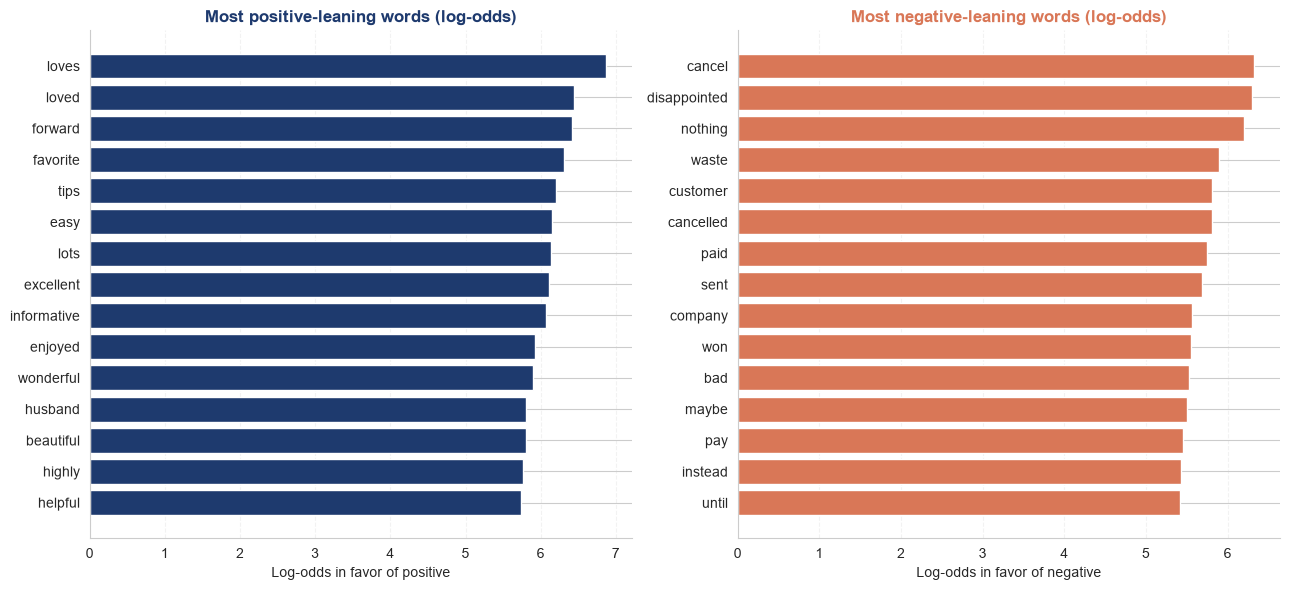

In [ ]:
pos_dict = dict(top_words(pos_texts.sample(n=min(10000, len(pos_texts)), random_state=RANDOM_STATE), n=300))
neg_dict = dict(top_words(neg_texts.sample(n=min(10000, len(neg_texts)), random_state=RANDOM_STATE), n=300))

all_words = set(pos_dict) | set(neg_dict)
pos_total = sum(pos_dict.values()) + len(all_words)
neg_total = sum(neg_dict.values()) + len(all_words)
log_odds = {}
for w in all_words:
    p_pos = (pos_dict.get(w, 0) + 1) / pos_total
    p_neg = (neg_dict.get(w, 0) + 1) / neg_total
    log_odds[w] = math.log(p_pos / p_neg)


MIN_FREQ = 30
filtered = {w: lo for w, lo in log_odds.items()
            if (pos_dict.get(w, 0) + neg_dict.get(w, 0)) >= MIN_FREQ}
sorted_lo = sorted(filtered.items(), key=lambda x: x[1])
top_neg_words = sorted_lo[:15]
top_pos_words = sorted_lo[-15:][::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
ax1.barh([w for w, _ in top_pos_words], [lo for _, lo in top_pos_words],
         color=NAVY, edgecolor='white', linewidth=1)
ax1.invert_yaxis()
ax1.set_title('Most positive-leaning words (log-odds)', fontsize=12, color=NAVY, fontweight='bold')
ax1.set_xlabel('Log-odds in favor of positive')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.25, linestyle='--')
ax1.set_axisbelow(True)

ax2.barh([w for w, _ in top_neg_words], [-lo for _, lo in top_neg_words],
         color=ORANGE, edgecolor='white', linewidth=1)
ax2.invert_yaxis()
ax2.set_title('Most negative-leaning words (log-odds)', fontsize=12, color=ORANGE, fontweight='bold')
ax2.set_xlabel('Log-odds in favor of negative')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.25, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'discriminative_words.png')
plt.show()

**Reading.** The discriminative words are semantically reasonable: positive-leaning words like *love*, *great*, *favorite*, *excellent* on one side, negative-leaning ones like *cancel*, *refund*, *waste*, *charged*, *terrible* on the other. Two things stand out.

The dataset clearly has learnable signal — a simple log-odds analysis already separates the classes meaningfully, which is a good sign for what TF-IDF + Logistic Regression should achieve in RQ1.

The negative side is also revealing in itself: words like *cancel*, *refund*, and *charged* are characteristic of subscription products — they relate to billing and renewal experiences rather than product properties. This previews what aspect-level analysis is likely to surface as a major aspect category in RQ2, alongside more conventional aspects like content quality or shipping.

## 8. Summary table

All key statistics in one place, saved to `results/tables/eda_summary.csv` for later reference (e.g., when writing the final paper).

In [14]:
summary_stats = {
    'total_reviews': len(df),
    'subscription_boxes': (df['category'] == 'Subscription_Boxes').sum(),
    'magazine_subscriptions': (df['category'] == 'Magazine_Subscriptions').sum(),
    'time_range': f"{df['date'].min().date()} to {df['date'].max().date()}",
    'verified_purchase_share': f"{df['verified_purchase'].mean():.1%}",
    'mean_review_length_words': round(df['review_length'].mean(), 1),
    'median_review_length_words': int(df['review_length'].median()),
    'star_5_share': f"{(df['rating'] == 5).mean():.1%}",
    'star_1_share': f"{(df['rating'] == 1).mean():.1%}",
    'binary_imbalance_ratio': f"{binary_counts['positive']/binary_counts['negative']:.2f} : 1",
    'ternary_neutral_share': f"{(df['rating'] == 3).mean():.1%}",
    'sample_vocab_corpus_freq_ge_5': sum(1 for c in vocab_counter.values() if c >= 5),
}

summary_df = pd.DataFrame([summary_stats]).T.rename(columns={0: 'value'})
summary_df.to_csv(TABLES_DIR / 'eda_summary.csv')
print('Summary saved to results/tables/eda_summary.csv\n')
print(summary_df.to_string())

Summary saved to results/tables/eda_summary.csv

                                                  value
total_reviews                                     87713
subscription_boxes                                16216
magazine_subscriptions                            71497
time_range                     2001-10-26 to 2023-08-30
verified_purchase_share                           82.7%
mean_review_length_words                           40.0
median_review_length_words                           22
star_5_share                                      60.8%
star_1_share                                      14.0%
binary_imbalance_ratio                         3.57 : 1
ternary_neutral_share                              7.7%
sample_vocab_corpus_freq_ge_5                      6308


## 9. Key takeaways for the interim presentation

**Dataset.** Combined dataset of ~87.7K reviews across two distinct categories. Subscription Boxes (~16K) is the smallest standalone category in the entire Amazon Reviews 2023 release; pairing it with Magazine Subscriptions (~71K) keeps the analysis tractable while enabling the cross-category comparison the topic description requires. Reviews span 2001–2023 (computed time range: 2001-10-26 to 2023-08-30) with strong concentration in recent years, which means a chronological train/test split is the appropriate choice.

**Class imbalance.** Star ratings are heavily skewed toward 5★ (≈60%), with ~14% 1★ and only ~8% 3★. Under a binary framing the positive-to-negative ratio is roughly 3.6 : 1 — moderately imbalanced. Under a ternary framing the 3★ neutral class is the minority at ~8%, and that's exactly the population RQ1 wants to investigate.

**Evaluation implications.** Reporting accuracy alone would mask poor performance on the minority class. A trivial *always-positive* baseline already reaches ~78% under binary framing — any classifier needs to be benchmarked against that floor. Primary metrics will be macro-F1 and per-class recall.

**Review length and vocabulary.** Reviews are short on average (median 22 words) but heavily right-skewed. This supports the sentence-level approach planned for RQ2. The sample vocabulary with corpus frequency >= 5 is in the low-thousands range; the actual TF-IDF feature counts are reported later from the training split.

**Discriminative-word sanity check.** Top positive-leaning words (*love*, *great*, *favorite*) and negative-leaning words (*cancel*, *refund*, *waste*, *charged*) are semantically reasonable. The negative-side vocabulary already hints at billing- and renewal-related aspects that RQ2 will pick up.

**Open points for the interim presentation.**
- *Sentiment framing:* binary or ternary? Binary is cleaner methodologically; ternary engages directly with RQ1's stated focus on mixed-sentiment 3★ reviews. Proposal: report both, lead with binary.
- *Aspect extraction:* keyword lexicon vs. noun-phrase chunking. Proposal: use the keyword lexicon for final assignment and noun-phrase chunking as exploratory candidate discovery/cross-check.
- *Verified-purchase filter:* whether to restrict to verified-purchase reviews to reduce noise from incentivized or fake reviews.
- *Item concentration in Subscription Boxes:* with only 641 items in that category, aspect frequencies could be dominated by a few popular boxes — worth flagging.